# Non-linear leak


A general, multi-ion current is described by the [GHK current equation](https://en.wikipedia.org/wiki/Goldman%E2%80%93Hodgkin%E2%80%93Katz_flux_equation):
\begin{align}
I = \sum_j^n P_j z_j^2 \frac{V F^2}{RT} \frac{C_{i, j} - C_{e, j} \exp(-z_i V F/RT)}{1- \exp(-z_i V F/RT)}
\end{align}
where $P$ is permeability, $z$ is valence, and $C_i$ and $C_e$ are internal and external concentrations.

Simplifying assumption: $z_j = 1$ for all $j$.

\begin{align}
I = \sum_j^n P_j \frac{V F^2}{RT} \frac{C_{i, j} - C_{e, j} \exp(-V F/(RT))}{1- \exp(-V F/(RT))}
\end{align}

Next, use $V_f = \frac{VF}{RT}$

\begin{align}
I &= \sum_j^n P_j V_f F \frac{C_{i, j} - C_{e, j} \exp(-V_f)}{1- \exp(-V_f)} \\
  &= \sum_j^n P_j V_f F C_{i, j} \frac{1 - \frac{C_{e, j}}{C_{i, j}} \exp(-V_f)}{1- \exp(-V_f)}
\end{align}

The terms in this sum have a nice symmetry around $r = C_e / C_i$, but only if we keep $C = C_e + C_i$ constant

\begin{align}
I &= \sum_j^n P_j V_f F C_{i, j} \frac{1 - \frac{C_{e, j}}{C_{i, j}} \exp(-V_f)}{1- \exp(-V_f)} \\
  &= \sum_j^n P_j V_f F C_j \frac{1}{1 + r_j} \frac{1 - r_j \exp(-V_f)}{1- \exp(-V_f)} \\
  &= \sum_j^n x_j V_f \frac{1 - r_j \exp(-V_f)}{(1 + r_j)(1 - \exp(-V_f))}
\end{align}


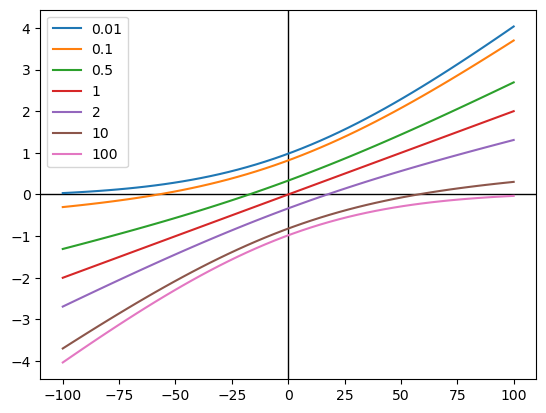

In [16]:
import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure()
ax = fig.add_subplot()
ax.axvline(0, color='k', lw=1)
ax.axhline(0, color='k', lw=1)

v = np.linspace(-100, 100)
vf = v / 25
evf = np.exp(-vf)
for r in (0.01, 0.1, 0.5, 1, 2, 10, 100):
    i = vf * 1 / (1 + r) * (1 - r * evf) / (1 - evf)
    ax.plot(v, i, label=f'{r}')

ax.legend()
plt.show()

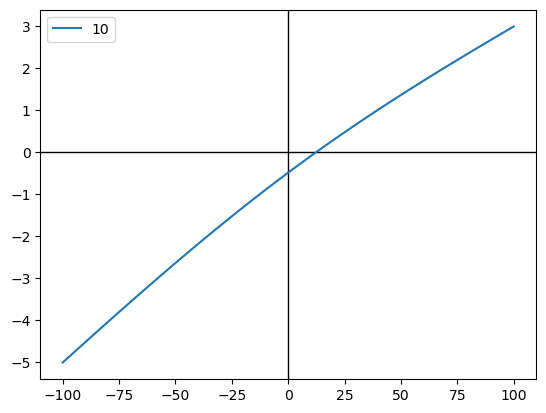

In [18]:
fig = plt.figure()
ax = fig.add_subplot()
ax.axvline(0, color='k', lw=1)
ax.axhline(0, color='k', lw=1)

v = np.linspace(-100, 100)
vf = v / 25
evf = np.exp(-vf)
i = np.zeros(v.shape)
for r in (0.5, 10):
    i += vf * 1 / (1 + r) * (1 - r * evf) / (1 - evf)
ax.plot(v, i, label=f'{r}')
ax.legend()
plt.show()

But this would require the current to be selective.